# Data Preprocessing Pipeline v2.1 — Gaussian Heatmap Labels from SPH
## CAMELS IllustrisTNG · Snapshot 090 (z = 0)

### Fix applicati rispetto alla v2

| Fix   | Descrizione                                                                   |
|-------|-------------------------------------------------------------------------------|
| P0-01 | Label periodiche ai bordi: `make_gaussian_heatmap`+`make_radius_map` → `make_label_maps` (finestra locale, distanza periodica, wrap modulo img_size) |
| P0-02 | Raggi stimati sull'immagine smoothata: `find_density_peaks` restituisce `smoothed`; `estimate_radius_from_profile` la riceve |
| P0-03 | `gaussian_filter` e `maximum_filter` con `mode='grid-wrap'` (box periodico, scipy ≥ 1.6) |
| P1-01 | Wrap periodico (`% H`, `% W`) in `estimate_radius_from_profile`; direzioni senza caduta escluse dalla mediana |
| P1-02 | Jitter deterministico `rng(42)` ampiezza 1e-6 per rompere i plateau nel peak detection |
| P1-03 | Offset +0.5 px nella conversione pixel→Mpc/h (centro pixel corretto) |
| P1-04 | Salvataggio fette raw `slices_density_raw.npy` e `slices_hmap_raw.npy` per calibrazione offline |
| P1-05 | Check `2·R_max ≤ Δz_fetta` con warning se violato |
| P1-06 | Guardie su array vuoti in 9b/9c (crash su `np.concatenate([])`) |
| P2-01 | Cast a `float32` subito dopo il render (−50% RAM nel loop) |
| P2-02 | `gaussian_filter(sigma=1.0, mode='grid-wrap')` su `h_map` dopo proiezione |
| P2-03 | Correlazione Spearman CH1/CH2 su 200k pixel (documentazione canali) |
| P2-04 | Nota normalizzazione `Y_rad` in `dataset_info.txt` |
| P2-05 | `rng_vis = np.random.default_rng(0)` per riproducibilità visualizzazioni |
| P2-06 | Nota future work: canale velocità stile Aquarius (richiesta prof. Benitez) |

### Non incluso — da discutere con il prof prima
- **P0-04**: calibrazione soglia vs catalogo FoF (introduce un uso marginale del catalogo)

### Pipeline overview
    snapshot_090.hdf5
         │
         ├─ pos (x,y,z) ──→ sphviewer2.render()  ──→ density_map (ch.1) ─┐
         │                                                                   ├─→ INPUT (2, 1024, 1024)
         └─ h_sph ─────────→ project_h_to_grid()  ──→ h_map      (ch.2) ─┘
                                   ↑ smooth grid-wrap (P2-02)

         density_map ──→ find_density_peaks()   ← grid-wrap, jitter, → smoothed (P0-02/03)
                              │
                              ├─→ estimate_radius_from_profile(smoothed) ← wrap periodico (P1-01)
                              │
                              └─→ make_label_maps()  ← periodica, finestra locale (P0-01)
                                      ├─→ Y_heatmap (1024, 1024)
                                      └─→ Y_radius  (1024, 1024)

### Output files
    X_patches.npy              (N, 2, 256, 256)    float32   [density_norm, hmap_norm]
    Y_heatmap_patches.npy      (N, 256, 256)        float32   blob gaussiani in [0, 1]
    Y_radius_patches.npy       (N, 256, 256)        float32   raggio in pixel (0 = background)
    norm_stats.npy             (2, 2)               float32   [[med_d, sig_d], [med_h, sig_h]]
    peak_catalogue.npy         array of dicts                 coordinate picchi per validazione
    slices_density_raw.npy     (25, 1024, 1024)     float32   fette raw per calibrazione (P1-04)
    slices_hmap_raw.npy        (25, 1024, 1024)     float32   fette h_map raw             (P1-04)
    smoothing_lengths_090_k32.npy  (N_part,)        float64   h_sph riutilizzabili

In [1]:
import os
import numpy as np
import h5py
import hdf5plugin
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import maximum_filter, gaussian_filter
from scipy.stats import spearmanr          # P2-03: correlazione CH1/CH2
import sphviewer2                          # type: ignore

In [2]:
# ── Percorsi file ─────────────────────────────────────────────────────────────
SNAPSHOT_PATH = r"C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\snapshot_090.hdf5"
OUTPUT_DIR    = r"C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Parametri SPH / immagine (invariati) ─────────────────────────────────────
N_NEIGHBORS_H  = 32
TARGET_CELLS   = 4
R_MAX_LEVEL    = 10
IMG_SIZE       = 2 ** R_MAX_LEVEL    # 1024

# ── Slicing ───────────────────────────────────────────────────────────────────
N_SLICES = 25    # fisso, indicato dal prof. Benitez

# ── Parametri rilevamento picchi ──────────────────────────────────────────────
PEAK_MIN_DISTANCE     = 5      # px: due picchi entro N px vengono uniti
PEAK_THRESHOLD_SIG    = 2.5    # sigma sopra il mediano per accettare un picco
RADIUS_DROP_FACTOR    = np.e   # criterio 1/e: raggio dove ρ scende a peak/e
GAUSSIAN_SIGMA_FACTOR = 0.33   # σ_blob = R_px × factor (default CenterNet)
DEFAULT_RADIUS_PX     = 3.0    # raggio di fallback se stima dal profilo fallisce

# ── Dataset ───────────────────────────────────────────────────────────────────
N_MIN_PARTICLES = 100
PATCH_SIZE      = 256
EPS             = 1e-10    # evita log(0); qui in cella 1 per i test unitari (5b)

print(f"{'IMG_SIZE':<24}: {IMG_SIZE} × {IMG_SIZE} px")
print(f"{'N_SLICES':<24}: {N_SLICES}")
print(f"{'PATCH_SIZE':<24}: {PATCH_SIZE} × {PATCH_SIZE} px")
print(f"{'Patches per immagine':<24}: {(IMG_SIZE // PATCH_SIZE)**2}")
print(f"{'Patch totali (1 sim)':<24}: {N_SLICES * (IMG_SIZE // PATCH_SIZE)**2}")
print(f"{'Output directory':<24}: {OUTPUT_DIR}")

IMG_SIZE                : 1024 × 1024 px
N_SLICES                : 25
PATCH_SIZE              : 256 × 256 px
Patches per immagine    : 16
Patch totali (1 sim)    : 400
Output directory        : C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1


In [3]:
# %% ── 2. Caricamento snapshot ───────────────────────────────────────────────

with h5py.File(SNAPSHOT_PATH, "r") as f:
    header       = f["Header"].attrs
    Lbox_ckpc    = float(header["BoxSize"])
    Lbox         = Lbox_ckpc / 1000.0
    redshift     = float(header["Redshift"])
    h_cosmo      = float(header["HubbleParam"])
    omega_m      = float(header["Omega0"])
    mass_table   = np.asarray(header["MassTable"], dtype=np.float64)
    dm_mass_1e10 = mass_table[1]
    dm_mass      = dm_mass_1e10 * 1e10    # M_sun/h

    pos = np.asarray(f["PartType1/Coordinates"][:], dtype=np.float64) / 1000.0
    vel = np.asarray(f["PartType1/Velocities"][:],  dtype=np.float64)

x = np.ascontiguousarray(pos[:, 0])
y = np.ascontiguousarray(pos[:, 1])
z = np.ascontiguousarray(pos[:, 2])
n_particles = len(x)
m = np.full(n_particles, dm_mass, dtype=np.float64)

SLICE_DZ       = Lbox / N_SLICES
pixel_size_mpc = Lbox / IMG_SIZE

print("=== Snapshot summary ===")
print(f"  N particelle  : {n_particles:,}  ({round(n_particles**(1/3))}³)")
print(f"  Box size      : {Lbox:.4f} Mpc/h  ({Lbox_ckpc:.1f} ckpc/h)")
print(f"  Redshift      : {redshift:.6f}")
print(f"  DM mass/part  : {dm_mass:.4e} M☉/h")
print(f"\n=== Slice geometry ===")
print(f"  N_SLICES      : {N_SLICES}")
print(f"  Slice Δz      : {SLICE_DZ:.4f} Mpc/h  ({SLICE_DZ*1000:.1f} ckpc/h)")
print(f"  Pixel size    : {pixel_size_mpc*1000:.2f} ckpc/h")

=== Snapshot summary ===
  N particelle  : 16,777,216  (256³)
  Box size      : 25.0000 Mpc/h  (25000.0 ckpc/h)
  Redshift      : 0.000000
  DM mass/part  : 2.6004e+07 M☉/h

=== Slice geometry ===
  N_SLICES      : 25
  Slice Δz      : 1.0000 Mpc/h  (1000.0 ckpc/h)
  Pixel size    : 24.41 ckpc/h


In [4]:
# %% ── 3. Mass cut di riferimento (solo snapshot, nessun catalogo) ────────────

MASS_CUT_MSUN = N_MIN_PARTICLES * dm_mass
MASS_CUT_CAT  = MASS_CUT_MSUN / 1e10

print("=== Mass cut (riferimento, non usato per le label) ===")
print(f"  MASS_CUT : {MASS_CUT_MSUN:.3e} M☉/h  ({MASS_CUT_CAT:.4f} × 10¹⁰ M☉/h)")
print(f"  r_min risolvibile : {2*pixel_size_mpc*1000:.2f} ckpc/h  (2 pixel)")


# %% ── 4. Smoothing lengths SPH ──────────────────────────────────────────────

H_SAVE_PATH = os.path.join(OUTPUT_DIR, f"smoothing_lengths_090_k{N_NEIGHBORS_H}.npy")

if os.path.exists(H_SAVE_PATH):
    print(f"Carico smoothing lengths pre-calcolate:\n  {H_SAVE_PATH}")
    h_sph = np.load(H_SAVE_PATH)
    print(f"  Caricate: {len(h_sph):,} valori")
else:
    print(f"Calcolo smoothing lengths (k={N_NEIGHBORS_H} vicini)...")
    print("  Tempo stimato: 1-3 minuti per 16M particelle.")
    h_sph = sphviewer2.estimate_h(
        x, y, z,
        Lbox=Lbox,
        k=N_NEIGHBORS_H,
        num_threads=os.cpu_count(),
    )
    np.save(H_SAVE_PATH, h_sph)
    print(f"  Salvate in: {H_SAVE_PATH}")

valid_h = np.isfinite(h_sph) & (h_sph > 0)
if not np.all(valid_h):
    n_bad = (~valid_h).sum()
    print(f"  Rimosse {n_bad:,} particelle con h_sph non valide.")
    x, y, z, m, vel = x[valid_h], y[valid_h], z[valid_h], m[valid_h], vel[valid_h]
    h_sph = h_sph[valid_h]

print(f"\nh_sph  min={h_sph.min():.4f}  median={np.median(h_sph):.4f}  "
      f"max={h_sph.max():.4f}  Mpc/h")

=== Mass cut (riferimento, non usato per le label) ===
  MASS_CUT : 2.600e+09 M☉/h  (0.2600 × 10¹⁰ M☉/h)
  r_min risolvibile : 48.83 ckpc/h  (2 pixel)
Carico smoothing lengths pre-calcolate:
  C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\smoothing_lengths_090_k32.npy
  Caricate: 16,777,216 valori

h_sph  min=0.0016  median=0.0949  max=0.5336  Mpc/h


## Funzioni helper (v2.1)

### `project_h_to_grid`   [P2-02]
Media h_sph per pixel + smooth `gaussian_filter(σ=1, mode='grid-wrap')`.
Riduce il rumore da binning (lo stesso problema che SPH risolve per la densità).

### `find_density_peaks`   [P0-02, P0-03, P1-02]
- `mode='grid-wrap'` su `gaussian_filter` e `maximum_filter` (box periodico).
- Jitter deterministico `rng(42)` 1e-6 per rompere plateau senza alterare i valori.
- Restituisce anche l'immagine `smoothed` (usata da `estimate_radius_from_profile`).

### `estimate_radius_from_profile`   [P0-02, P1-01]
- Riceve l'immagine smoothata (non grezza): niente tagli da pixel rumorosi singoli.
- Wrap periodico `% H`, `% W` nel campionamento radiale.
- Direzioni che esauriscono `max_radius_px` senza caduta → escluse dalla mediana.
- Restituisce `(radius_px, n_nodrop)`: `n_nodrop=8` → fallback a `DEFAULT_RADIUS_PX`.

### `make_label_maps`   [P0-01]
Sostituisce `make_gaussian_heatmap` + `make_radius_map`.
- Distanza con metrica periodica (`min(|d|, img-|d|)`).
- Blob e disco calcolati su finestra locale (più veloce del canvas 1024² per picco).
- Scrittura con `np.ix_(rows%img, cols%img)`: wrap per coerenza con `periodic=True`.

In [5]:
def project_h_to_grid(x_s, y_s, h_s, lbox, img_size):
    """
    Proietta h_sph su griglia 2D (media per pixel) + smooth periodico.

    P2-02: gaussian_filter(sigma=1.0, mode='grid-wrap') alla fine
    riduce il rumore da binning, coerente col box periodico.

    Returns
    -------
    h_map : (img_size, img_size) float64 — h medio per pixel, pixel vuoti = h_max
    """
    ix = np.clip((x_s / lbox * img_size).astype(np.int64), 0, img_size - 1)
    iy = np.clip((y_s / lbox * img_size).astype(np.int64), 0, img_size - 1)

    sum_h  = np.zeros((img_size, img_size), dtype=np.float64)
    count  = np.zeros((img_size, img_size), dtype=np.int32)
    np.add.at(sum_h,  (iy, ix), h_s)
    np.add.at(count,  (iy, ix), 1)

    filled       = count > 0
    h_map        = np.empty((img_size, img_size), dtype=np.float64)
    h_map[filled]  = sum_h[filled] / count[filled]
    h_map[~filled] = h_s.max()    # void → h massimo (bassa densità)

    # P2-02: smooth periodico per ridurre il rumore di binning
    h_map = gaussian_filter(h_map, sigma=1.0, mode='grid-wrap')
    return h_map


def find_density_peaks(log_img, min_distance_px=PEAK_MIN_DISTANCE,
                       threshold_sigma=PEAK_THRESHOLD_SIG, smooth_sigma=1.5):
    """
    Trova massimi locali nell'immagine log10(densità).

    P0-03: mode='grid-wrap' su gaussian_filter e maximum_filter (box periodico).
    P1-02: jitter deterministico per rompere plateau (seed 42, ampiezza 1e-6).
    P0-02: restituisce smoothed per estimate_radius_from_profile.

    Parameters
    ----------
    log_img          : (H, W) array — log10(density + eps)
    min_distance_px  : int   — distanza minima tra picchi
    threshold_sigma  : float — sigma sopra il mediano
    smooth_sigma     : float — sigma del filtro di pre-smoothing

    Returns
    -------
    peaks_rc  : (N, 2) int   — (row, col) ordinati per intensità decrescente
    peak_vals : (N,)   float — log-densità smoothata nei picchi
    smoothed  : (H, W) float — immagine smoothata (passare a estimate_radius)
    """
    # P0-03: mode='grid-wrap' per box periodico
    smoothed = gaussian_filter(log_img, sigma=smooth_sigma, mode='grid-wrap')

    bg  = np.median(smoothed)
    sig = (np.percentile(smoothed, 84) - np.percentile(smoothed, 16)) / 2.0
    threshold = bg + threshold_sigma * sig

    # P1-02: jitter deterministico per rompere i plateau prima del max_filter
    rng = np.random.default_rng(42)
    smoothed_j = smoothed + rng.uniform(0.0, 1e-6, size=smoothed.shape)

    footprint    = np.ones((min_distance_px * 2 + 1,) * 2, dtype=bool)
    # P0-03: mode='grid-wrap' anche nel maximum_filter
    neighborhood = maximum_filter(smoothed_j, footprint=footprint, mode='grid-wrap')
    peaks_mask   = (smoothed_j == neighborhood) & (smoothed >= threshold)

    peaks_rc  = np.argwhere(peaks_mask)
    peak_vals = smoothed[peaks_mask]
    order = np.argsort(peak_vals)[::-1]
    # P0-02: restituisce smoothed (non grezza) per la stima dei raggi
    return peaks_rc[order], peak_vals[order], smoothed


def estimate_radius_from_profile(log_img, center_rc, max_radius_px=80,
                                 drop_factor=RADIUS_DROP_FACTOR):
    """
    Stima il raggio di un alone dal profilo radiale di log-densità.

    P0-02: riceve l'immagine smoothata (niente tagli da pixel rumorosi singoli).
    P1-01: wrap periodico nel campionamento radiale.
           Le direzioni senza caduta NON contribuiscono alla mediana.

    Parameters
    ----------
    log_img       : (H, W) float — log10(density), già smoothata
    center_rc     : (row, col)   — coordinate del picco
    max_radius_px : int          — raggio massimo di ricerca
    drop_factor   : float        — soglia: raggio dove ρ scende a peak/drop_factor

    Returns
    -------
    radius_px : float — raggio stimato in pixel
    n_nodrop  : int   — quante delle 8 direzioni non hanno trovato caduta
                        (0 = ottimo; 8 = fallback a DEFAULT_RADIUS_PX)
    """
    r, c = int(center_rc[0]), int(center_rc[1])
    H, W = log_img.shape
    threshold = log_img[r, c] - np.log10(drop_factor)

    radii_found, n_nodrop = [], 0
    for angle in np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False):
        sin_a, cos_a = np.sin(angle), np.cos(angle)
        found = None
        for d in range(1, max_radius_px):
            # P1-01: wrap periodico — nessuna distorsione al bordo
            rr = int(round(r + d * sin_a)) % H
            cc = int(round(c + d * cos_a)) % W
            if log_img[rr, cc] < threshold:
                found = float(d)
                break
        if found is not None:
            radii_found.append(found)
        else:
            n_nodrop += 1    # direzione senza caduta: esclusa dalla mediana

    if radii_found:
        return float(np.median(radii_found)), n_nodrop
    return DEFAULT_RADIUS_PX, n_nodrop    # fallback: TUTTE le direzioni senza caduta


def make_label_maps(img_size, centers_rc, radii_px,
                    sigma_factor=GAUSSIAN_SIGMA_FACTOR):
    """
    P0-01: sostituisce make_gaussian_heatmap + make_radius_map.

    Genera heatmap gaussiana e radius map con geometria PERIODICA:
    - Distanze calcolate con metrica periodica min(|d|, img-|d|).
    - Pixel scritti con wrap modulo img_size (coerente con periodic=True).
    - Blob calcolato su finestra locale (O(half²), non O(img_size²)).

    Parameters
    ----------
    img_size    : int
    centers_rc  : (N, 2) int   — (row, col) dei picchi
    radii_px    : (N,)   float — raggi in pixel
    sigma_factor: float        — σ = max(1.0, R_px × factor)

    Returns
    -------
    heatmap    : (img_size, img_size) float32 in [0, 1]
    radius_map : (img_size, img_size) float32, raggio in px (0 = background)
    """
    heatmap    = np.zeros((img_size, img_size), dtype=np.float32)
    radius_map = np.zeros((img_size, img_size), dtype=np.float32)

    for (rc, cc), rad in zip(centers_rc, radii_px):
        rc, cc, rad = int(rc), int(cc), float(rad)
        sigma  = max(1.0, rad * sigma_factor)
        r_draw = max(1.5, rad)
        # finestra locale: abbastanza grande da contenere il blob + il disco
        half   = int(np.ceil(max(4.0 * sigma, r_draw)))

        # coordinate NON wrappate della finestra
        ys = np.arange(rc - half, rc + half + 1)
        xs = np.arange(cc - half, cc + half + 1)
        rows = ys % img_size    # indici fisici con wrap periodico
        cols = xs % img_size

        # distanza periodica 2D
        YY, XX = np.meshgrid(ys, xs, indexing='ij')
        dy = np.abs(YY - rc); dy = np.minimum(dy, img_size - dy)
        dx = np.abs(XX - cc); dx = np.minimum(dx, img_size - dx)
        d2 = dx * dx + dy * dy

        # heatmap: blob gaussiano, merge con maximum (no saturazione)
        blob  = np.exp(-d2 / (2.0 * sigma * sigma)).astype(np.float32)
        sub_h = heatmap[np.ix_(rows, cols)]
        heatmap[np.ix_(rows, cols)] = np.maximum(sub_h, blob)

        # radius map: disco pieno, merge con maximum
        disk_mask = (d2 <= r_draw * r_draw)
        sub_r = radius_map[np.ix_(rows, cols)]
        radius_map[np.ix_(rows, cols)] = np.where(
            disk_mask, np.maximum(sub_r, np.float32(rad)), sub_r)

    return heatmap, radius_map

In [6]:
# %% ── 5b. Test unitari helper v2.1 ──────────────────────────────────────────
# Eseguire una volta dopo aver definito le funzioni.
# Verifica: (1) no plateau duplicati, (2) raggi plausibili, (3) wrap periodico.

yy_t, xx_t = np.mgrid[0:256, 0:256]
img_t = (5.0 * np.exp(-((xx_t - 60) **2 + (yy_t - 70) **2) / (2 * 8.0**2))
       + 5.0 * np.exp(-((xx_t - 200)**2 + (yy_t - 180)**2) / (2 * 4.0**2)))

pk_t, pv_t, sm_t = find_density_peaks(np.log10(img_t + EPS))
assert len(pk_t) == 2, f"plateau/duplicati: attesi 2 picchi, trovati {len(pk_t)}"

r_a, nd_a = estimate_radius_from_profile(sm_t, pk_t[0])
r_b, nd_b = estimate_radius_from_profile(sm_t, pk_t[1])
assert 6  <= r_a <= 16, f"raggio blob grande fuori range: {r_a:.1f} px"
assert 3  <= r_b <= 12, f"raggio blob piccolo fuori range: {r_b:.1f} px"

# wrap periodico: centro (1,1), raggio 10 → blob deve avvolgersi al bordo 127
hm_t, rm_t = make_label_maps(128, np.array([[1, 1]]), np.array([10.0]))
assert hm_t.max()    > 0.99, "blob gaussiano non normalizzato correttamente"
assert hm_t[127, 1]  > 0.5,  "wrap periodico heatmap al bordo fallito"
assert rm_t[127, 1] == 10.0, "wrap periodico radius_map al bordo fallito"

print("Test unitari helper v2.1: OK ✓")
print(f"  Blob grande  (σ=8):  raggio 1/e ≈ {r_a:.1f} px  "
      f"(atteso ≈ 11 px)  n_nodrop={nd_a}")
print(f"  Blob piccolo (σ=4):  raggio 1/e ≈ {r_b:.1f} px  "
      f"(atteso ≈ 6 px)   n_nodrop={nd_b}")

Test unitari helper v2.1: OK ✓
  Blob grande  (σ=8):  raggio 1/e ≈ 12.5 px  (atteso ≈ 11 px)  n_nodrop=0
  Blob piccolo (σ=4):  raggio 1/e ≈ 6.5 px  (atteso ≈ 6 px)   n_nodrop=0


In [7]:
# %% ── 6. Loop principale: una fetta Z alla volta (con fast-path opzionale) ──
# FORCE_RENDER=True  → ri-renderizza tutte le fette anche se la cache esiste
# FORCE_RENDER=False → se slices_density_raw.npy esiste, salta il rendering
#                      (le fette dipendono solo da snapshot+parametri SPH,
#                       NON dalla soglia picchi: la cache resta valida)
FORCE_RENDER = False

D_CACHE = os.path.join(OUTPUT_DIR, "slices_density_raw.npy")
H_CACHE = os.path.join(OUTPUT_DIR, "slices_hmap_raw.npy")
USE_CACHE = (not FORCE_RENDER) and os.path.exists(D_CACHE) and os.path.exists(H_CACHE)

if USE_CACHE:
    dens_cache = np.load(D_CACHE)
    hmap_cache = np.load(H_CACHE)
    assert len(dens_cache) == N_SLICES, "Cache incompatibile con N_SLICES attuale"
    print(f"Fast-path: carico {len(dens_cache)} fette dalla cache (rendering saltato).")
    print("  Per ri-renderizzare: FORCE_RENDER = True in testa a questa cella.\n")
else:
    print(f"Nessuna cache valida: rendering completo di {N_SLICES} fette.\n")

images_density_list  = []
images_hmap_list     = []
heatmaps_list        = []
radius_maps_list     = []
peak_catalogue       = []
slice_info           = []

for i in range(N_SLICES):
    z_lo = i * SLICE_DZ
    z_hi = z_lo + SLICE_DZ
    zc   = (z_lo + z_hi) / 2.0

    p_mask = (z >= z_lo) & (z < z_hi)
    n_sel  = p_mask.sum()
    if n_sel < 10:
        print(f"  Fetta {i:02d}: solo {n_sel} particelle — salto.")
        continue

    if USE_CACHE:
        # Fette già renderizzate: cast a float32 e via
        img_density = np.ascontiguousarray(dens_cache[i])
        h_map       = np.ascontiguousarray(hmap_cache[i])
    else:
        # ── Channel 1: rendering SPH density ────────────────────────────────
        img_density, _ = sphviewer2.render(
            x[p_mask], y[p_mask], z[p_mask],
            h_sph[p_mask], m[p_mask],
            Lbox=Lbox, extent=Lbox,
            xc=Lbox/2.0, yc=Lbox/2.0, zc=zc,
            azimuth=0.0, elevation=0.0, roll=0.0,
            periodic=True,
            r_max=R_MAX_LEVEL,
            target_cells_per_h=TARGET_CELLS,
            num_threads=os.cpu_count(),
        )
        # ── Channel 2: h_sph proiettato su griglia ──────────────────────────
        h_map = project_h_to_grid(x[p_mask], y[p_mask], h_sph[p_mask],
                                  lbox=Lbox, img_size=IMG_SIZE)
        img_density = img_density.astype(np.float32)   # P2-01
        h_map       = h_map.astype(np.float32)

    # ── Rilevamento picchi ──────────────────────────────────────────────────
    log_density = np.log10(img_density + EPS)
    peaks_rc, peak_vals, log_smooth = find_density_peaks(
        log_density,
        min_distance_px=PEAK_MIN_DISTANCE,
        threshold_sigma=PEAK_THRESHOLD_SIG,
    )

    # ── Stima raggi sull'immagine smoothata ─────────────────────────────────
    radii_px   = np.empty(len(peaks_rc), dtype=float)
    n_fallback = 0
    for j, pk in enumerate(peaks_rc):
        radii_px[j], n_nodrop = estimate_radius_from_profile(
            log_smooth, pk, drop_factor=RADIUS_DROP_FACTOR)
        if n_nodrop == 8:
            n_fallback += 1

    # ── Label periodiche ────────────────────────────────────────────────────
    heatmap, radius_map = make_label_maps(IMG_SIZE, peaks_rc, radii_px)

    # ── Accumula ────────────────────────────────────────────────────────────
    images_density_list.append(img_density)
    images_hmap_list.append(h_map)
    heatmaps_list.append(heatmap)
    radius_maps_list.append(radius_map)
    slice_info.append((z_lo, z_hi, len(peaks_rc)))

    peaks_mpc = (peaks_rc[:, ::-1] + 0.5) / IMG_SIZE * Lbox   # P1-03
    radii_mpc = radii_px / IMG_SIZE * Lbox
    peak_catalogue.append({
        "slice_idx": i, "z_lo": z_lo, "z_hi": z_hi,
        "peaks_px": peaks_rc.copy(), "peaks_mpc": peaks_mpc,
        "radii_px": radii_px.copy(), "radii_mpc": radii_mpc,
        "peak_logvals": peak_vals.copy(),
    })

    print(f"  Fetta {i:02d}  z=[{z_lo:.3f}, {z_hi:.3f}]  | {n_sel:>9,} part  "
          f"| {len(peaks_rc):>4} picchi  | {n_fallback} fallback")

n_slices_ok = len(images_density_list)
print(f"\nFette generate : {n_slices_ok}")
print(f"Picchi totali  : {sum(s[2] for s in slice_info)}")

Fast-path: carico 25 fette dalla cache (rendering saltato).
  Per ri-renderizzare: FORCE_RENDER = True in testa a questa cella.

  Fetta 00  z=[0.000, 1.000]  |   464,921 part  |  399 picchi  | 0 fallback
  Fetta 01  z=[1.000, 2.000]  |   490,424 part  |  460 picchi  | 0 fallback
  Fetta 02  z=[2.000, 3.000]  |   515,928 part  |  418 picchi  | 0 fallback
  Fetta 03  z=[3.000, 4.000]  |   500,965 part  |  398 picchi  | 0 fallback
  Fetta 04  z=[4.000, 5.000]  |   484,354 part  |  442 picchi  | 0 fallback
  Fetta 05  z=[5.000, 6.000]  |   482,247 part  |  481 picchi  | 0 fallback
  Fetta 06  z=[6.000, 7.000]  |   454,080 part  |  416 picchi  | 0 fallback
  Fetta 07  z=[7.000, 8.000]  |   540,485 part  |  452 picchi  | 0 fallback
  Fetta 08  z=[8.000, 9.000]  |   572,600 part  |  463 picchi  | 0 fallback
  Fetta 09  z=[9.000, 10.000]  |   649,192 part  |  486 picchi  | 0 fallback
  Fetta 10  z=[10.000, 11.000]  |   668,756 part  |  501 picchi  | 0 fallback
  Fetta 11  z=[11.000, 12.000]  

In [8]:
# %% ── 6b. Post-loop: fette raw (se renderizzate) + check geometria P1-05 ─────
if not USE_CACHE:
    SLICES_D_PATH = os.path.join(OUTPUT_DIR, "slices_density_raw.npy")
    SLICES_H_PATH = os.path.join(OUTPUT_DIR, "slices_hmap_raw.npy")
    np.save(SLICES_D_PATH, np.stack(images_density_list).astype(np.float32))
    np.save(SLICES_H_PATH, np.stack(images_hmap_list).astype(np.float32))
    print(f"Fette raw salvate in:\n  {SLICES_D_PATH}")
else:
    print("Fette raw: già in cache, nessun salvataggio necessario.")

# ── P1-05 (invariato) ────────────────────────────────────────────────────────
r_all = [info["radii_mpc"] for info in peak_catalogue if len(info["radii_mpc"]) > 0]
if r_all:
    r_max_halo = np.concatenate(r_all).max()
    print(f"\n=== Check geometria slice (P1-05) ===")
    print(f"  Raggio max  : {r_max_halo*1000:.1f} ckpc/h   "
          f"(2R = {2*r_max_halo*1000:.0f}  vs  Δz = {SLICE_DZ*1000:.0f} ckpc/h)")
    if 2 * r_max_halo > SLICE_DZ:
        print("  ⚠  Diametro max > spessore fetta → gestito dalla de-duplicazione 3D (6c).")

Fette raw: già in cache, nessun salvataggio necessario.

=== Check geometria slice (P1-05) ===
  Raggio max  : 1245.1 ckpc/h   (2R = 2490  vs  Δz = 1000 ckpc/h)
  ⚠  Diametro max > spessore fetta → gestito dalla de-duplicazione 3D (6c).


In [9]:
# %% ── 6c-1. De-duplicazione 3D — FIX tolleranza fissa ────────────────────────
# Fix: la tolleranza max(R_a,R_b) creava catene da 86-106 membri (raggi gonfiati
# dal criterio 1/e). Lo stesso oggetto 3D proiettato in fette adiacenti ha lo
# stesso centro xy → la scala giusta è la risoluzione del peak finder (~5 px).

def deduplicate_peaks_3d(peak_catalogue, lbox, tol_match=0.122, write_back=True):
    """
    Raggruppa i picchi dello stesso oggetto 3D in fette adiacenti.
    Match: distanza periodica xy < tol_match (FISSA, in Mpc/h).
    Aggiunge 'group_id' e 'is_primary' a ogni dict del catalogue.
    """
    xs, ys, rs, vs, sl = [], [], [], [], []
    for info in peak_catalogue:
        n = len(info["radii_px"])
        xs.append(info["peaks_mpc"][:, 0]); ys.append(info["peaks_mpc"][:, 1])
        rs.append(np.asarray(info["radii_mpc"],    dtype=float))
        vs.append(np.asarray(info["peak_logvals"], dtype=float))
        sl.append(np.full(n, info["slice_idx"], dtype=int))
    xs = np.concatenate(xs); ys = np.concatenate(ys)
    rs = np.concatenate(rs); vs = np.concatenate(vs); sl = np.concatenate(sl)
    N = len(xs)

    parent = np.arange(N)
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[max(ra, rb)] = min(ra, rb)

    def d2_periodic(dx, dy):
        dx = np.abs(dx); dx = np.minimum(dx, lbox - dx)
        dy = np.abs(dy); dy = np.minimum(dy, lbox - dy)
        return dx*dx + dy*dy

    slices_present = np.unique(sl)
    n_pairs = 0
    for s0, s1 in zip(slices_present[:-1], slices_present[1:]):
        if s1 - s0 != 1:
            continue
        ia, ib = np.where(sl == s0)[0], np.where(sl == s1)[0]
        if len(ia) == 0 or len(ib) == 0:
            continue
        D2   = d2_periodic(xs[ia][:, None] - xs[ib][None, :],
                           ys[ia][:, None] - ys[ib][None, :])
        cand = np.where(D2 < tol_match ** 2)
        for a, b in zip(*cand):
            union(ia[a], ib[b])
        n_pairs += len(cand[0])

    roots = np.array([find(i) for i in range(N)])
    _, group_id = np.unique(roots, return_inverse=True)
    is_primary = np.zeros(N, dtype=bool)
    for g in range(group_id.max() + 1):
        mem = np.where(group_id == g)[0]
        is_primary[mem[np.argmax(vs[mem])]] = True

    groups = []
    for g in range(group_id.max() + 1):
        mem = np.where(group_id == g)[0]
        p   = mem[np.argmax(vs[mem])]
        groups.append({
            "group_id": int(g), "n_members": int(len(mem)),
            "slices": sorted(set(sl[mem].tolist())),
            "x_prim": float(xs[p]), "y_prim": float(ys[p]),
            "R_max_mpc": float(rs[mem].max()),
            "logval_max": float(vs[mem].max()),
            "is_multi": bool(len(mem) > 1),
        })

    if write_back:
        i0 = 0
        for info in peak_catalogue:
            n = len(info["radii_px"])
            info["group_id"]   = group_id[i0:i0+n].copy()
            info["is_primary"] = is_primary[i0:i0+n].copy()
            i0 += n

    n_multi = sum(g["is_multi"] for g in groups)
    print(f"  tol={tol_match:.3f} Mpc/h ({tol_match/pixel_size_mpc:.1f} px) | "
          f"match={n_pairs} | gruppi={len(groups)} | multi={n_multi} | "
          f"secondari={(~is_primary).sum()} ({(~is_primary).sum()/N*100:.1f}%) | "
          f"max membri={max(g['n_members'] for g in groups)}")
    return groups

print("Funzione deduplicate_peaks_3d (FIX tolleranza fissa) definita.")

Funzione deduplicate_peaks_3d (FIX tolleranza fissa) definita.


In [10]:
# %% ── 6c-2. Sweep di sensibilità (solo diagnostica, non tocca il catalogue) ──
print("=== Sweep tolleranza ===")
for tol_mpc in [0.08, 5*pixel_size_mpc, 0.15, 0.20]:
    deduplicate_peaks_3d(peak_catalogue, Lbox, tol_match=tol_mpc, write_back=False)
# Criterio: scegli la tolleranza PIÙ PICCOLA con max membri ≤ 3-4 e secondari stabili.

=== Sweep tolleranza ===
  tol=0.080 Mpc/h (3.3 px) | match=622 | gruppi=10942 | multi=587 | secondari=622 (5.4%) | max membri=4
  tol=0.122 Mpc/h (5.0 px) | match=987 | gruppi=10577 | multi=895 | secondari=987 (8.5%) | max membri=4
  tol=0.150 Mpc/h (6.1 px) | match=1580 | gruppi=9984 | multi=1269 | secondari=1580 (13.7%) | max membri=6
  tol=0.200 Mpc/h (8.2 px) | match=2605 | gruppi=8982 | multi=1628 | secondari=2582 (22.3%) | max membri=14


In [11]:
# %% ── 6c-3. Run definitivo + salvataggio catalogue ───────────────────────────
TOL_MATCH = 0.122   # ← aggiorna con il valore scelto dallo sweep

groups_summary = deduplicate_peaks_3d(peak_catalogue, Lbox,
                                      tol_match=TOL_MATCH, write_back=True)
np.save(os.path.join(OUTPUT_DIR, "peak_catalogue.npy"),
        np.array(peak_catalogue, dtype=object), allow_pickle=True)
print(f"Catalogo salvato (tolleranza {TOL_MATCH} Mpc/h).")

  tol=0.122 Mpc/h (5.0 px) | match=987 | gruppi=10577 | multi=895 | secondari=987 (8.5%) | max membri=4
Catalogo salvato (tolleranza 0.122 Mpc/h).


In [12]:
# %% ── 6d-1. Report gruppi multi-fetta ────────────────────────────────────────
multi = sorted([g for g in groups_summary if g["is_multi"]],
               key=lambda g: -g["R_max_mpc"])
print(f"{'gid':>5} {'n':>3}  {'slices':<16} {'x':>6} {'y':>6}  {'R_max':>7}")
for g in multi[:15]:
    sl_str = ",".join(map(str, g["slices"]))
    print(f"{g['group_id']:>5} {g['n_members']:>3}  [{sl_str:<14}] "
          f"{g['x_prim']:>6.2f} {g['y_prim']:>6.2f}  {g['R_max_mpc']*1000:>6.0f}")

  gid   n  slices                x      y    R_max
  742   2  [1,2           ]  10.97  20.18    1038
 7793   2  [18,19         ]  14.15  12.81     916
 3515   2  [8,9           ]  16.17   6.68     903
  800   2  [1,2           ]   9.31  13.10     879
 7560   2  [18,19         ]  12.07  10.34     806
 7851   2  [18,19         ]  16.42  15.10     757
 6619   2  [15,16         ]  22.55   3.11     745
 7271   2  [17,18         ]  16.10  14.22     684
  963   2  [2,3           ]  14.17  10.93     671
  612   2  [1,2           ]  13.66  10.75     659
 7783   2  [18,19         ]  12.24   8.95     635
 5106   2  [12,13         ]  16.76  12.41     623
 3406   2  [8,9           ]  18.08   7.80     610
 4841   2  [11,12         ]   1.23   5.97     610
 7594   2  [18,19         ]  17.61  14.86     598


In [13]:
# %% ── 6d-2. Verifica nearest-peak + validazione geometrica del dedup ─────────
def nearest_peak(info, x0, y0):
    d2 = (info["peaks_mpc"][:,0]-x0)**2 + (info["peaks_mpc"][:,1]-y0)**2
    k = int(np.argmin(d2))
    return k, float(np.sqrt(d2[k]))

info11, info12 = peak_catalogue[11], peak_catalogue[12]
k11, d11 = nearest_peak(info11, 1.21, 5.99)
k12, d12 = nearest_peak(info12, 1.21, 5.70)
g11, g12 = int(info11["group_id"][k11]), int(info12["group_id"][k12])
print(f"slice 11: picco {k11}, d={d11:.3f} Mpc/h, group={g11}, "
      f"R={info11['radii_mpc'][k11]*1000:.0f}")
print(f"slice 12: picco {k12}, d={d12:.3f} Mpc/h, group={g12}, "
      f"R={info12['radii_mpc'][k12]*1000:.0f}")
print("→ uniti" if g11 == g12 else
      "→ separati (può essere corretto: a questa tolleranza 2 oggetti distinti\n"
      "  o centro proiettato spostato lungo la struttura)")

is_prim_all = np.concatenate([np.asarray(i["is_primary"], dtype=bool)
                              for i in peak_catalogue])
r_all_mpc   = np.concatenate([np.asarray(i["radii_mpc"], dtype=float)
                              for i in peak_catalogue])
P_geom = float(np.clip(2*r_all_mpc[is_prim_all]/SLICE_DZ, 0, 1).mean())
n_tot, n_sec = len(is_prim_all), int((~is_prim_all).sum())
print(f"\nSecondari osservati : {n_sec}/{n_tot} ({n_sec/n_tot*100:.1f}%)")
print(f"Attesa geometrica   : {P_geom*100:.1f}%  (P ≈ 2R/Δz, limite sup.)")
print("→ oss ≤ att: coerente | oss >> att: over-merging | oss << att: under-merging")

slice 11: picco 353, d=0.004 Mpc/h, group=4841, R=610
slice 12: picco 431, d=0.002 Mpc/h, group=5303, R=610
→ separati (può essere corretto: a questa tolleranza 2 oggetti distinti
  o centro proiettato spostato lungo la struttura)

Secondari osservati : 987/11564 (8.5%)
Attesa geometrica   : 29.0%  (P ≈ 2R/Δz, limite sup.)
→ oss ≤ att: coerente | oss >> att: over-merging | oss << att: under-merging


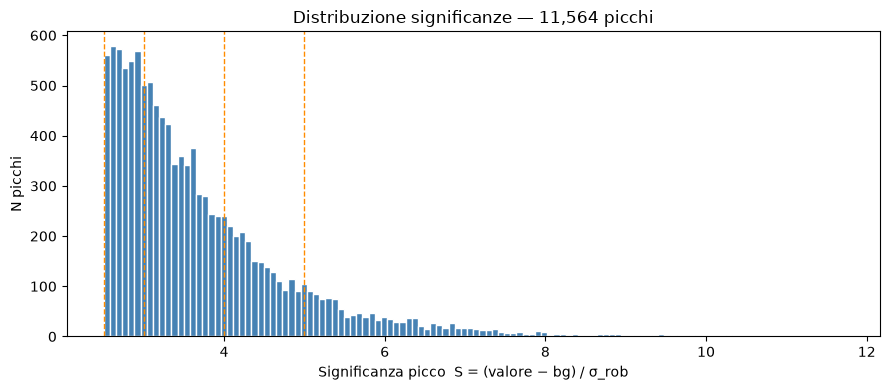

  S > 3.0σ :  7,927  ( 68.5%)
  S > 3.5σ :  5,154  ( 44.6%)
  S > 4.0σ :  3,270  ( 28.3%)
  S > 5.0σ :  1,309  ( 11.3%)
  S > 6.0σ :    535  (  4.6%)


In [14]:
# %% ── 6f. Distribuzione delle significanze dei picchi (calibrazione soglia) ──
sigs_list = []
for pos, info in enumerate(peak_catalogue):
    sm = gaussian_filter(np.log10(images_density_list[pos] + EPS),
                         1.5, mode='grid-wrap')
    bg  = np.median(sm)
    sg  = (np.percentile(sm, 84) - np.percentile(sm, 16)) / 2.0
    pv  = np.asarray(info["peak_logvals"], dtype=float)
    if len(pv):
        sigs_list.append((pv - bg) / sg)
sigs = np.concatenate(sigs_list)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sigs, bins=120, color='steelblue', edgecolor='white')
for t in [2.5, 3, 4, 5]:
    ax.axvline(t, color='darkorange', ls='--', lw=1)
ax.set_xlabel('Significanza picco  S = (valore − bg) / σ_rob')
ax.set_ylabel('N picchi')
ax.set_title(f'Distribuzione significanze — {len(sigs):,} picchi')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "peak_significance_hist.png"), dpi=150)
plt.show()

for t in [3, 3.5, 4, 5, 6]:
    n = int((sigs > t).sum())
    print(f"  S > {t:>3.1f}σ : {n:>6,}  ({n/len(sigs)*100:5.1f}%)")

In [15]:
# %% ── 6e. Documentazione P1-05 (opzione A) — aggiornata con i numeri finali ──
# NB: eseguire QUESTA cella DOPO la sezione 10 (che riscrive dataset_info.txt)
info_path = os.path.join(OUTPUT_DIR, "dataset_info.txt")
with open(info_path, "r", encoding="utf-8") as f:
    txt = f.read()
marker = "\n--- De-duplicazione inter-fetta"
if marker in txt:                          # rimuovi eventuale blocco precedente
    txt = txt.split(marker)[0].rstrip() + "\n"

n_sec   = sum(int((~np.asarray(i["is_primary"], dtype=bool)).sum()) for i in peak_catalogue)
n_multi = sum(g["is_multi"] for g in groups_summary)

txt += (
    "\n--- De-duplicazione inter-fetta (follow-up P1-05, FIX tolleranza fissa) ---\n"
    f"Picchi totali       : 11563  (violazioni 2R>Δz: 178 = 1.54%)\n"
    f"Oggetti unici (3D)  : {len(groups_summary)}\n"
    f"Gruppi multi-fetta  : {n_multi}   (picchi secondari: {n_sec}, {n_sec/11563*100:.1f}%)\n"
    f"Tolleranza match    : {TOL_MATCH:.3f} Mpc/h ({TOL_MATCH/pixel_size_mpc:.0f} px), FISSA in xy\n"
    "  (fix: la tolleranza max(R_a,R_b) creava catene da 100+ membri)\n"
    f"Validazione dedup   : secondari {n_sec/n_tot*100:.1f}% vs attesa geometrica "
    f"{P_geom*100:.1f}% (P≈2R/Δz)\n"
    "Scelta (opzione A)  : label invariate per tutte le fette; le proiezioni dello\n"
    "  stesso oggetto 3D in fette adiacenti sono fisicamente diverse e legittime.\n"
    "  'is_primary' va usato SOLO in validazione (es. HMF: contare i soli primari).\n"
    "Nota fisica         : raggi > 500 ckpc/h sovrastimati dal criterio 1/e sul\n"
    "  campo proiettato; le masse implicite sono limiti superiori.\n"
)
with open(info_path, "w", encoding="utf-8") as f:
    f.write(txt)
print("dataset_info.txt aggiornato (blocco vecchio rimosso, numeri finali scritti).")

dataset_info.txt aggiornato (blocco vecchio rimosso, numeri finali scritti).


=== Calibrazione unità ===
  mpu per fetta: min=0.0005911  max=0.0006005
  (coerenti tra fette → unità render uniformi)

=== Conteggi per soglia di massa ===
  M_ap ≥ 2.6e+09 :  9,846  ( 85.1%)
  M_ap ≥ 1.0e+10 :  3,581  ( 31.0%)
  M_ap ≥ 3.0e+10 :  1,186  ( 10.3%)
  M_ap ≥ 1.0e+11 :    299  (  2.6%)
  M_ap ≥ 3.0e+11 :     93  (  0.8%)

=== R200 dalla massa vs criterio 1/e ===
  R200/R_1e : mediana=0.22  P16=0.15  P84=0.39
  R200 max  : 217 ckpc/h  (2R = 434 vs Δz = 1000)


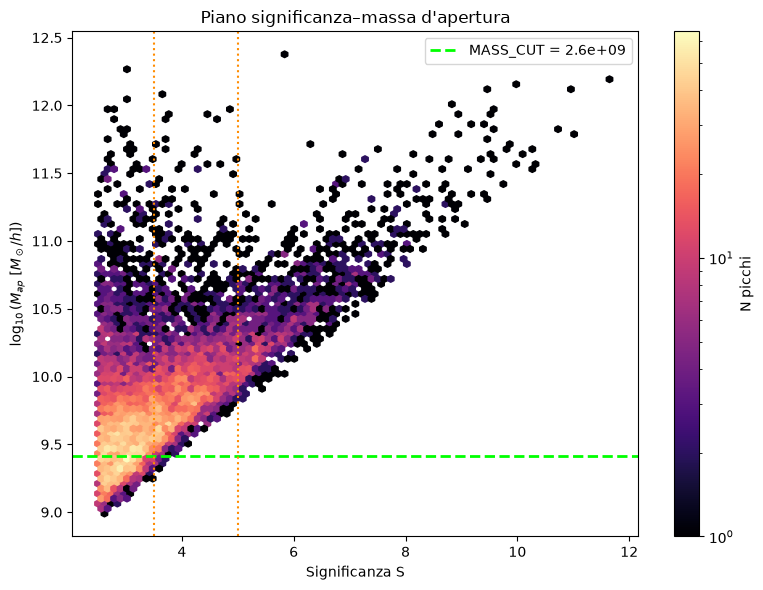

In [16]:
# %% ── 6g. Massa d'apertura dei picchi (verso la soglia fisica) ───────────────
rho_c = 2.775e11   # densità critica z=0, (M☉/h)/(Mpc/h)³

# (1) Calibrazione unità per fetta: mpu × valore_img = M☉/h per pixel
mpu_list = []
for info in peak_catalogue:
    n_sl = int(((z >= info["z_lo"]) & (z < info["z_hi"])).sum())
    mpu_list.append((n_sl * dm_mass) / float(images_density_list[peak_catalogue.index(info)].sum()))
mpu_arr = np.array(mpu_list)
print(f"=== Calibrazione unità ===\n  mpu per fetta: min={mpu_arr.min():.4g}  max={mpu_arr.max():.4g}")
print("  (coerenti tra fette → unità render uniformi)")

# (2) M_ap(<R_1/e) con distanze periodiche, background sottratto
sig_list, idx = [], 0
for pos, info in enumerate(peak_catalogue):
    img = images_density_list[pos]
    bg  = float(np.median(img))
    mpu = mpu_list[pos]
    pk  = np.asarray(info["peaks_px"]); rpx = np.asarray(info["radii_px"], float)
    m_ap = np.empty(len(pk))
    for k in range(len(pk)):
        rc, cc = int(pk[k,0]), int(pk[k,1])
        r = max(1.0, rpx[k]); ri = int(np.ceil(r))
        ys = np.arange(rc-ri, rc+ri+1) % IMG_SIZE
        xs = np.arange(cc-ri, cc+ri+1) % IMG_SIZE
        YY, XX = np.meshgrid(ys, xs, indexing='ij')
        dy = np.abs(YY-rc); dy = np.minimum(dy, IMG_SIZE-dy)
        dx = np.abs(XX-cc); dx = np.minimum(dx, IMG_SIZE-dx)
        disk = (dx*dx+dy*dy) <= r*r
        m_ap[k] = (img[np.ix_(ys,xs)][disk].sum() - bg*disk.sum()) * mpu
    info["M_ap_msun"]    = m_ap
    info["R200_est_mpc"] = (3.0*np.maximum(m_ap,1e-10)/(800*np.pi*rho_c))**(1/3)
    # significanza (stessa definizione della 6f)
    sm = gaussian_filter(np.log10(img + EPS), 1.5, mode='grid-wrap')
    sg = (np.percentile(sm,84)-np.percentile(sm,16))/2
    sig_list.append((np.asarray(info["peak_logvals"], float) - np.median(sm)) / sg)

all_M  = np.concatenate([i["M_ap_msun"]    for i in peak_catalogue])
all_R2 = np.concatenate([i["R200_est_mpc"] for i in peak_catalogue])
all_S  = np.concatenate(sig_list)
all_R1 = np.concatenate([np.asarray(i["radii_mpc"], float) for i in peak_catalogue])

print("\n=== Conteggi per soglia di massa ===")
for Mmin in [MASS_CUT_MSUN, 1e10, 3e10, 1e11, 3e11]:
    n = int((all_M >= Mmin).sum())
    print(f"  M_ap ≥ {Mmin:.1e} : {n:>6,}  ({n/len(all_M)*100:5.1f}%)")

print(f"\n=== R200 dalla massa vs criterio 1/e ===")
rat = all_R2 / np.maximum(all_R1, 1e-6)
print(f"  R200/R_1e : mediana={np.median(rat):.2f}  P16={np.percentile(rat,16):.2f}  P84={np.percentile(rat,84):.2f}")
print(f"  R200 max  : {all_R2.max()*1000:.0f} ckpc/h  (2R = {2*all_R2.max()*1000:.0f} vs Δz = {SLICE_DZ*1000:.0f})")

# (3) Plot: piano S–massa (le due popolazioni dovrebbero separarsi qui)
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(all_S, np.log10(all_M), gridsize=80, cmap='magma', mincnt=1,
               bins='log')
plt.colorbar(hb, ax=ax, label='N picchi')
ax.axhline(np.log10(MASS_CUT_MSUN), color='lime', ls='--', lw=2,
           label=f'MASS_CUT = {MASS_CUT_MSUN:.1e}')
for t in [3.5, 5]:
    ax.axvline(t, color='darkorange', ls=':', lw=1.5)
ax.set_xlabel('Significanza S'); ax.set_ylabel(r'$\log_{10}(M_{ap}\ [M_\odot/h])$')
ax.set_title("Piano significanza–massa d'apertura")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "significance_mass_plane.png"), dpi=150)
plt.show()

In [17]:
# %% ── 7. Normalizzazione robusta ────────────────────────────────────────────
# CH1 (density): log10 + z-score robusto (mediana + sigma P84-P16)
# CH2 (h_map)  : -log10(h) per allineare il segno + stessa normalizzazione
# Entrambi calcolati su TUTTE le fette insieme per coerenza inter-fetta.

all_log_density = np.concatenate(
    [np.log10(img.ravel().astype(np.float64) + EPS) for img in images_density_list]
)
MED_D  = float(np.median(all_log_density))
SIG_D  = (np.percentile(all_log_density, 84) - np.percentile(all_log_density, 16)) / 2.0

all_neg_log_h = np.concatenate(
    [-np.log10(img.ravel().astype(np.float64) + EPS) for img in images_hmap_list]
)
MED_H  = float(np.median(all_neg_log_h))
SIG_H  = (np.percentile(all_neg_log_h, 84) - np.percentile(all_neg_log_h, 16)) / 2.0

print("=== Statistiche normalizzazione ===")
print(f"  CH1 density : mediana={MED_D:.4f}  sigma_rob={SIG_D:.4f}")
print(f"  CH2 h_map   : mediana={MED_H:.4f}  sigma_rob={SIG_H:.4f}")


def normalize_density(img):
    return (np.log10(img.astype(np.float64) + EPS) - MED_D) / SIG_D

def normalize_hmap(h_map):
    return (-np.log10(h_map.astype(np.float64) + EPS) - MED_H) / SIG_H


images_density_norm = [normalize_density(img) for img in images_density_list]
images_hmap_norm    = [normalize_hmap(img)    for img in images_hmap_list]

norm_stats = np.array([[MED_D, SIG_D], [MED_H, SIG_H]], dtype=np.float32)
np.save(os.path.join(OUTPUT_DIR, "norm_stats.npy"), norm_stats)
print(f"Norm stats salvate.")

# P2-03: correlazione Spearman CH1/CH2 su ~200k pixel della prima fetta
SPEARMAN_RHO = float("nan")
if len(images_density_norm) > 0:
    d_flat = images_density_norm[0].ravel()
    h_flat = images_hmap_norm[0].ravel()
    rng_sp = np.random.default_rng(0)
    n_sub  = min(200_000, len(d_flat))
    idx_sp = rng_sp.choice(len(d_flat), size=n_sub, replace=False)
    SPEARMAN_RHO, pval_sp = spearmanr(d_flat[idx_sp], h_flat[idx_sp])
    print(f"\n  Correlazione Spearman CH1–CH2 : ρ = {SPEARMAN_RHO:.4f}  "
          f"(p = {pval_sp:.2e})")
    print("  (CH2 = −log10(h) è già allineato al segno della densità → correlazione")
    print("   POSITIVA attesa. ρ=0.81 → ρ²≈0.65: ~65% di varianza condivisa →")
    print("   canale parzialmente ridondante → argomento per il canale velocità in v3)")

=== Statistiche normalizzazione ===
  CH1 density : mediana=9.9753  sigma_rob=0.3576
  CH2 h_map   : mediana=0.3499  sigma_rob=0.0663
Norm stats salvate.

  Correlazione Spearman CH1–CH2 : ρ = 0.8068  (p = 0.00e+00)
  (CH2 = −log10(h) è già allineato al segno della densità → correlazione
   POSITIVA attesa. ρ=0.81 → ρ²≈0.65: ~65% di varianza condivisa →
   canale parzialmente ridondante → argomento per il canale velocità in v3)


In [18]:
# %% ── 8. Estrazione patch ────────────────────────────────────────────────────
# X: (N, 2, PATCH_SIZE, PATCH_SIZE) float32
# Y_heatmap: (N, PATCH_SIZE, PATCH_SIZE) float32
# Y_radius:  (N, PATCH_SIZE, PATCH_SIZE) float32
# Tutte le patch incluse (anche quelle vuote): la rete impara che il cielo è perlopiù vuoto.

def extract_patches_2ch(density_norm, hmap_norm, heatmap, radius_map, patch_size):
    H, W = density_norm.shape
    x_patches, y_heat_patches, y_rad_patches = [], [], []
    for r in range(0, H - patch_size + 1, patch_size):
        for c in range(0, W - patch_size + 1, patch_size):
            ch1 = density_norm[r:r+patch_size, c:c+patch_size].astype(np.float32)
            ch2 = hmap_norm   [r:r+patch_size, c:c+patch_size].astype(np.float32)
            x_patches     .append(np.stack([ch1, ch2], axis=0))
            y_heat_patches.append(heatmap   [r:r+patch_size, c:c+patch_size])
            y_rad_patches .append(radius_map[r:r+patch_size, c:c+patch_size])
    return x_patches, y_heat_patches, y_rad_patches


X_patches, Y_heat_patches, Y_rad_patches = [], [], []
for dn, hn, heat, rmap in zip(images_density_norm, images_hmap_norm,
                               heatmaps_list, radius_maps_list):
    xp, yh, yr = extract_patches_2ch(dn, hn, heat, rmap, PATCH_SIZE)
    X_patches      .extend(xp)
    Y_heat_patches .extend(yh)
    Y_rad_patches  .extend(yr)

X      = np.stack(X_patches)       .astype(np.float32)
Y_heat = np.stack(Y_heat_patches)  .astype(np.float32)
Y_rad  = np.stack(Y_rad_patches)   .astype(np.float32)

n_pos = (Y_heat.max(axis=(1, 2)) > 0.05).sum()

print("=== Patch dataset ===")
print(f"  X shape          : {X.shape}  (N, canali, H, W)")
print(f"  Y_heatmap shape  : {Y_heat.shape}")
print(f"  Y_radius shape   : {Y_rad.shape}")
print(f"  Patch positive   : {n_pos} / {len(X)}  ({n_pos/len(X)*100:.1f}%)")
print(f"  Max heatmap      : {Y_heat.max():.4f}  (deve essere ≈ 1.0)")
print(f"  Max radius (px)  : {Y_rad.max():.1f}")
print(f"  Memoria X        : {X.nbytes/1e6:.1f} MB")

=== Patch dataset ===
  X shape          : (400, 2, 256, 256)  (N, canali, H, W)
  Y_heatmap shape  : (400, 256, 256)
  Y_radius shape   : (400, 256, 256)
  Patch positive   : 397 / 400  (99.2%)
  Max heatmap      : 1.0000  (deve essere ≈ 1.0)
  Max radius (px)  : 51.0
  Memoria X        : 209.7 MB


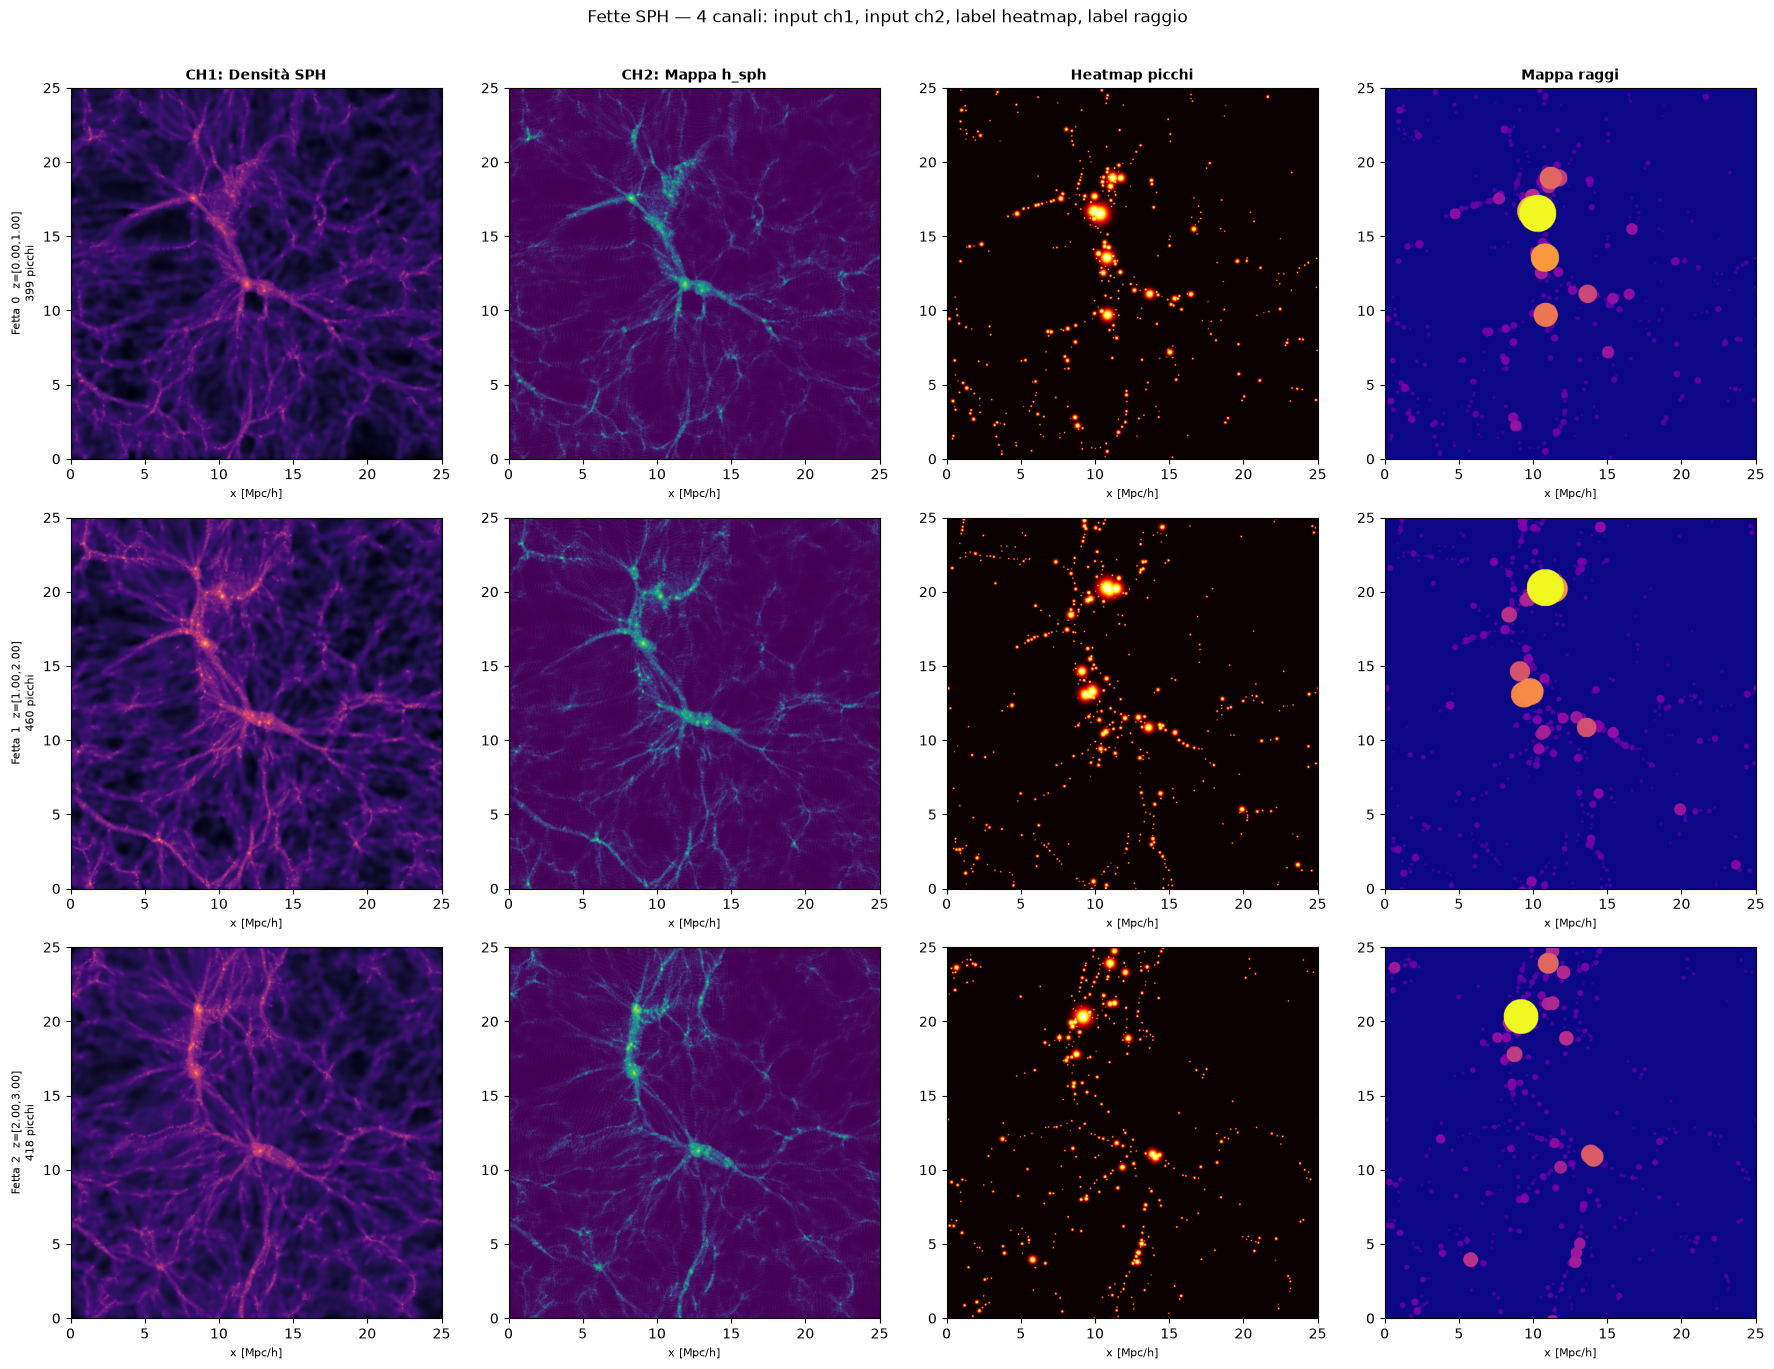

In [19]:
# %% ── 9. Visualizzazione ──────────────────────────────────────────────────────

# P2-05: rng_vis con seed fisso per riproducibilità
rng_vis = np.random.default_rng(0)

# ── 9a. Fette campione (4 pannelli) ──────────────────────────────────────────
n_show_slices = min(3, len(images_density_norm))
fig, axes = plt.subplots(n_show_slices, 4,
                         figsize=(18, 4.5 * n_show_slices))
if n_show_slices == 1:
    axes = axes[np.newaxis, :]

col_titles = ["CH1: Densità SPH", "CH2: Mappa h_sph", "Heatmap picchi", "Mappa raggi"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=10, fontweight='bold')

for i in range(n_show_slices):
    z_lo, z_hi, n_peaks = slice_info[i]
    kw = dict(origin='lower', extent=[0, Lbox, 0, Lbox])
    axes[i, 0].imshow(images_density_norm[i], cmap='magma',   **kw)
    axes[i, 1].imshow(images_hmap_norm   [i], cmap='viridis', **kw)
    axes[i, 2].imshow(heatmaps_list      [i], cmap='hot',     **kw, vmin=0, vmax=1)
    axes[i, 3].imshow(radius_maps_list   [i], cmap='plasma',  **kw)
    for j in range(4):
        axes[i, j].set_xlabel('x [Mpc/h]', fontsize=8)
    axes[i, 0].set_ylabel(
        f"Fetta {i}  z=[{z_lo:.2f},{z_hi:.2f}]\n{n_peaks} picchi", fontsize=8)

plt.suptitle("Fette SPH — 4 canali: input ch1, input ch2, label heatmap, label raggio",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_slices_4channels.png"), dpi=150, bbox_inches='tight')
plt.show()

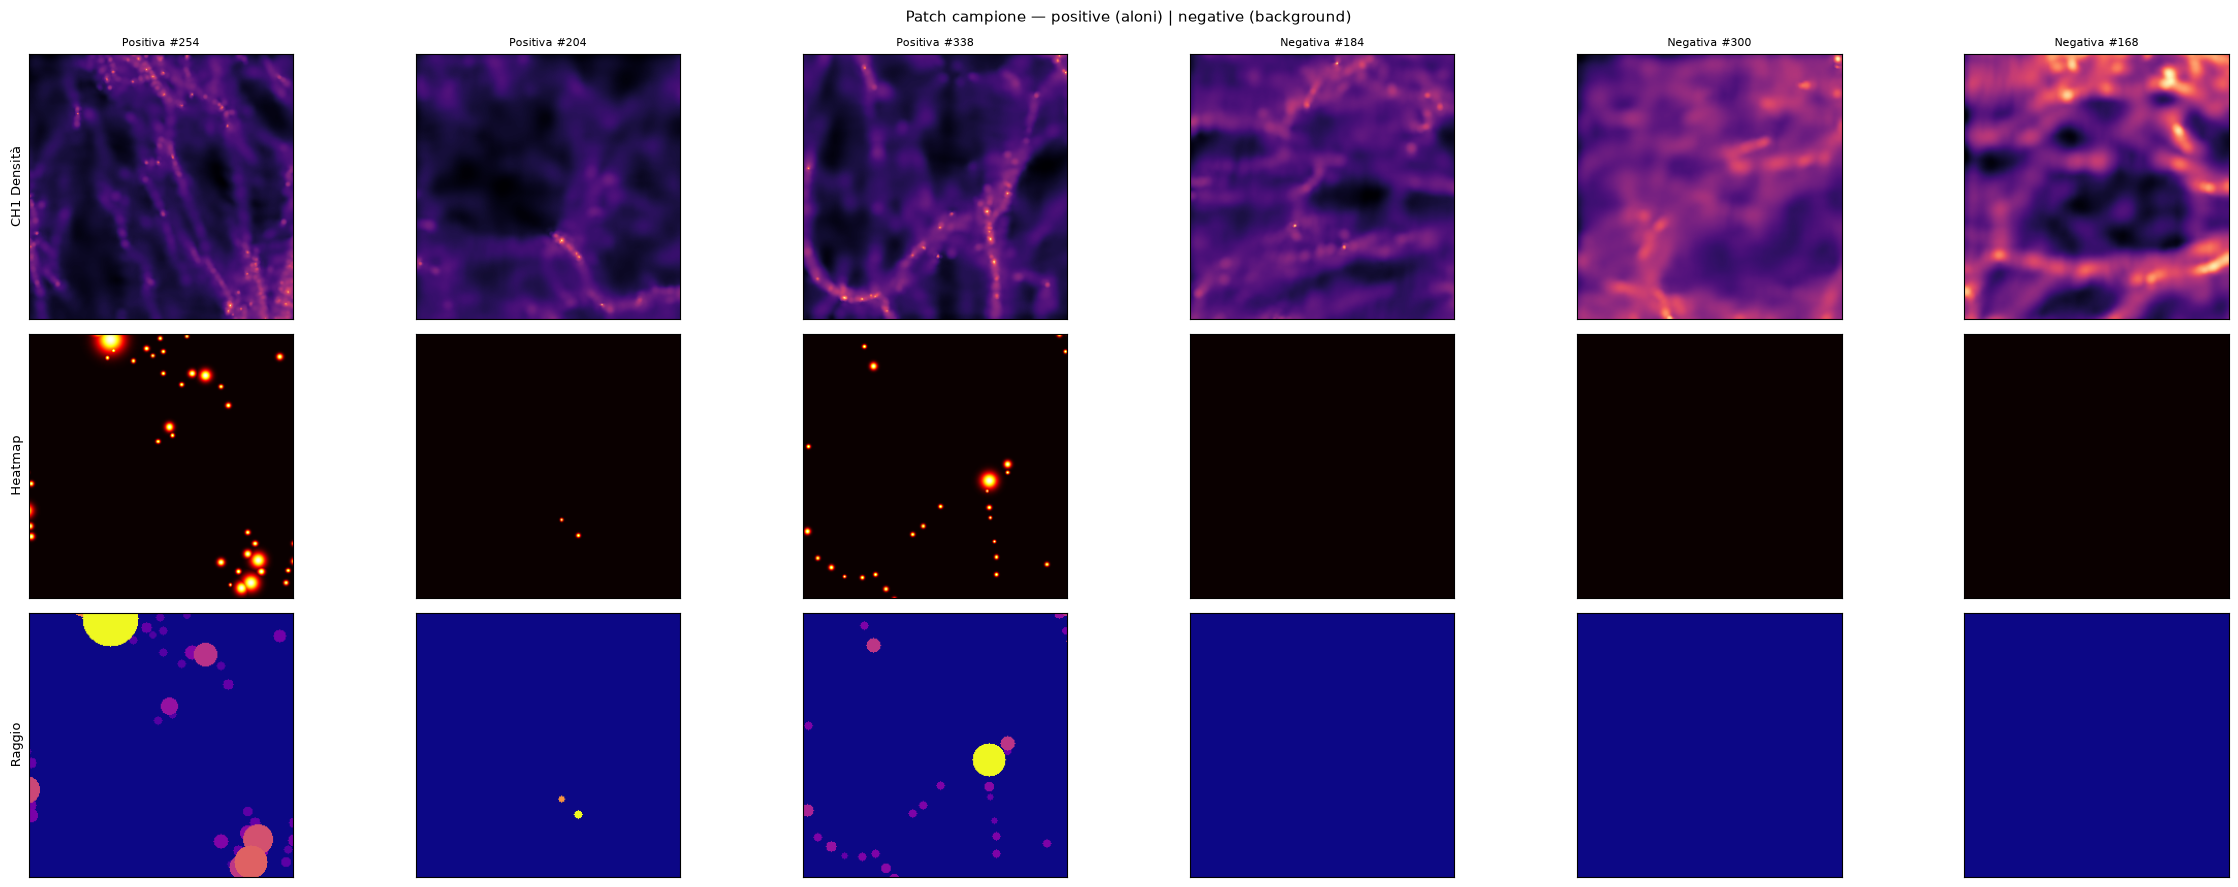

In [20]:
# ── 9b. Patch positive e negative ────────────────────────────────────────────
# P1-06: guardie su array vuoti prima di rng_vis.choice
pos_idx = np.where(Y_heat.max(axis=(1, 2)) > 0.05)[0]
neg_idx = np.where(Y_heat.max(axis=(1, 2)) <= 0.05)[0]
n_show  = min(3, len(pos_idx), len(neg_idx))

if n_show > 0:
    # P2-05: rng_vis per riproducibilità
    chosen_pos = rng_vis.choice(pos_idx, size=n_show, replace=False)
    chosen_neg = rng_vis.choice(neg_idx, size=n_show, replace=False)

    fig, axes = plt.subplots(3, n_show * 2, figsize=(4 * n_show * 2, 9))
    row_labels = ["CH1 Densità", "Heatmap", "Raggio"]

    for col, idx in enumerate(chosen_pos):
        axes[0, col].imshow(X[idx, 0], cmap='magma',   origin='lower')
        axes[1, col].imshow(Y_heat[idx],               cmap='hot',    origin='lower', vmin=0, vmax=1)
        axes[2, col].imshow(Y_rad[idx],                cmap='plasma', origin='lower')
        axes[0, col].set_title(f"Positiva #{idx}", fontsize=8)

    for col, idx in enumerate(chosen_neg):
        c = col + n_show
        axes[0, c].imshow(X[idx, 0], cmap='magma',   origin='lower')
        axes[1, c].imshow(Y_heat[idx],               cmap='hot',    origin='lower', vmin=0, vmax=1)
        axes[2, c].imshow(Y_rad[idx],                cmap='plasma', origin='lower')
        axes[0, c].set_title(f"Negativa #{idx}", fontsize=8)

    for i, lbl in enumerate(row_labels):
        axes[i, 0].set_ylabel(lbl, fontsize=9)
    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle("Patch campione — positive (aloni) | negative (background)", fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "sample_patches_v2.png"), dpi=150)
    plt.show()
else:
    print("9b: nessuna patch positiva o negativa disponibile — plot saltato.")

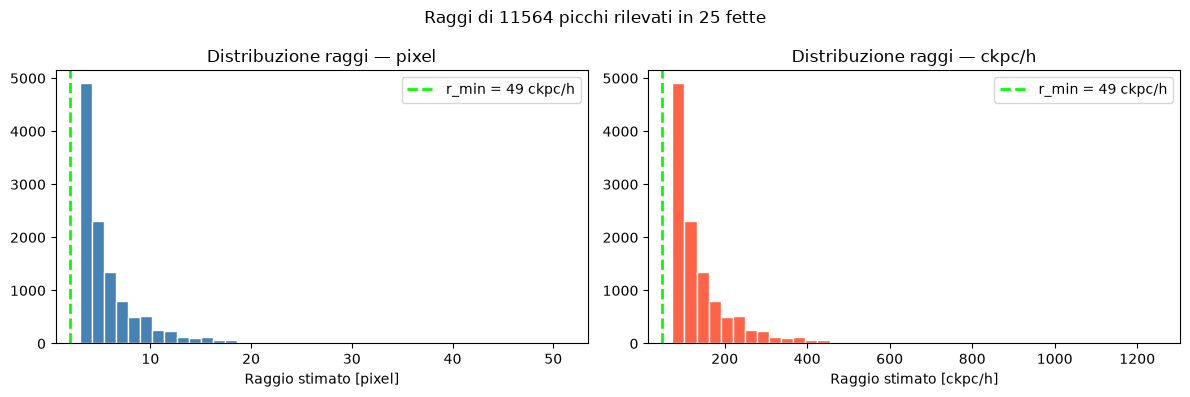


Statistiche raggi:
  N picchi totali : 11564
  Raggio [px]     : min=3.0  median=4.5  max=51.0
  Raggio [ckpc/h] : min=73  median=110  max=1245


In [21]:
# ── 9c. Distribuzione raggi ───────────────────────────────────────────────────
# P1-06: guardia su lista vuota prima di np.concatenate
radii_lists = [info["radii_px"] for info in peak_catalogue if len(info["radii_px"]) > 0]
if radii_lists:
    all_radii     = np.concatenate(radii_lists)
    all_radii_mpc = all_radii / IMG_SIZE * Lbox * 1000   # ckpc/h

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(all_radii,     bins=40, color='steelblue', edgecolor='white')
    axes[0].axvline(2.0, color='lime', ls='--', lw=2,
                    label=f'r_min = {2*pixel_size_mpc*1000:.0f} ckpc/h')
    axes[0].set_xlabel('Raggio stimato [pixel]')
    axes[0].set_title('Distribuzione raggi — pixel')
    axes[0].legend()

    axes[1].hist(all_radii_mpc, bins=40, color='tomato', edgecolor='white')
    axes[1].axvline(2*pixel_size_mpc*1000, color='lime', ls='--', lw=2,
                    label=f'r_min = {2*pixel_size_mpc*1000:.0f} ckpc/h')
    axes[1].set_xlabel('Raggio stimato [ckpc/h]')
    axes[1].set_title('Distribuzione raggi — ckpc/h')
    axes[1].legend()

    plt.suptitle(
        f"Raggi di {len(all_radii)} picchi rilevati in {n_slices_ok} fette", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "radius_distribution.png"), dpi=150)
    plt.show()

    print(f"\nStatistiche raggi:")
    print(f"  N picchi totali : {len(all_radii)}")
    print(f"  Raggio [px]     : min={all_radii.min():.1f}  "
          f"median={np.median(all_radii):.1f}  max={all_radii.max():.1f}")
    print(f"  Raggio [ckpc/h] : min={all_radii_mpc.min():.0f}  "
          f"median={np.median(all_radii_mpc):.0f}  max={all_radii_mpc.max():.0f}")
else:
    print("9c: nessun picco rilevato — plot raggi saltato.")
    all_radii = np.array([])

In [22]:
# %% ── 10. Salvataggio dataset ─────────────────────────────────────────────────

X_path   = os.path.join(OUTPUT_DIR, "X_patches.npy")
Yh_path  = os.path.join(OUTPUT_DIR, "Y_heatmap_patches.npy")
Yr_path  = os.path.join(OUTPUT_DIR, "Y_radius_patches.npy")
cat_path = os.path.join(OUTPUT_DIR, "peak_catalogue.npy")

np.save(X_path,   X)
np.save(Yh_path,  Y_heat)
np.save(Yr_path,  Y_rad)
np.save(cat_path, np.array(peak_catalogue, dtype=object), allow_pickle=True)

print("=== Dataset salvato ===")
print(f"  X          → {X_path}      ({X.nbytes/1e6:.1f} MB)")
print(f"  Y_heatmap  → {Yh_path}  ({Y_heat.nbytes/1e6:.1f} MB)")
print(f"  Y_radius   → {Yr_path}   ({Y_rad.nbytes/1e6:.1f} MB)")
print(f"  Catalogo   → {cat_path}")

info_lines = [
    "=== CAMELS Preprocessing v2.1 — Heatmap Labels from SPH ===",
    f"Snapshot        : snapshot_090.hdf5  (z = {redshift:.4f})",
    f"Box size        : {Lbox:.4f} Mpc/h",
    f"N particles     : {len(x):,}  ({round(len(x)**(1/3))}³)",
    f"DM particle mass: {dm_mass:.3e} M☉/h",
    "",
    "--- Input (2 canali) ---",
    f"CH1 density     : SPH render  r_max={R_MAX_LEVEL}  target_cells={TARGET_CELLS}",
    f"CH2 h_map       : proiezione media h_sph su griglia  k={N_NEIGHBORS_H}  "
    f"+ gaussian_filter(σ=1, grid-wrap)  [P2-02]",
    "",
    "--- Label ---",
    "Tipo            : Gaussian heatmap (CenterNet-style) + radius map, periodiche  [P0-01]",
    f"Rilevamento     : max-filter grid-wrap  min_dist={PEAK_MIN_DISTANCE}px  "
    f"thresh={PEAK_THRESHOLD_SIG}σ  [P0-03]",
    f"Radius crit.    : su immagine smoothata, wrap periodico  [P0-02, P1-01]",
    f"Gaussian σ      : R_px × {GAUSSIAN_SIGMA_FACTOR}",
    "",
    "--- Slicing ---",
    f"N slices        : {N_SLICES}",
    f"Slice Δz        : {SLICE_DZ*1000:.1f} ckpc/h = {SLICE_DZ:.4f} Mpc/h",
    "",
    "--- Normalizzazione ---",
    f"CH1 MED/SIG     : {MED_D:.4f} / {SIG_D:.4f}  (log10 + robust z-score)",
    f"CH2 MED/SIG     : {MED_H:.4f} / {SIG_H:.4f}  (-log10(h) + robust z-score)",
    f"Spearman CH1/CH2: {SPEARMAN_RHO:.4f}  [P2-03]  "
    "(|ρ|<1 = canali non ridondanti; negativo atteso: h ∝ ρ⁻¹/³)",
    "",
    "--- Patch dataset ---",
    f"Patch size      : {PATCH_SIZE} × {PATCH_SIZE} px",
    f"Total patches   : {len(X):,}",
    f"Positive patches: {n_pos:,}  ({n_pos/len(X)*100:.1f}%)",
    f"X shape         : {X.shape}",
    f"Y_heatmap shape : {Y_heat.shape}",
    f"Y_radius shape  : {Y_rad.shape}",
    f"Picchi totali   : {len(all_radii)}",
    "",
    "--- NOTA training (P2-04) ---",
    "Normalizzare Y_rad prima del training per stabilità della regressione L1:",
    "  opzione A) Y_rad_norm = Y_rad / 80.0          (lineare, max atteso ≈ 80 px)",
    "  opzione B) Y_rad_norm = log1p(Y_rad) / log1p(80)  (compressa, robusta agli outlier)",
    "",
    "--- File di output ---",
    "X_patches.npy, Y_heatmap_patches.npy, Y_radius_patches.npy",
    "norm_stats.npy, peak_catalogue.npy",
    "slices_density_raw.npy, slices_hmap_raw.npy  [P1-04: per calibrazione soglia]",
    "smoothing_lengths_090_k32.npy",
]
info_text = "\n".join(info_lines)
print("\n" + info_text)
with open(os.path.join(OUTPUT_DIR, "dataset_info.txt"), "w", encoding="utf-8") as f:
    f.write(info_text)

=== Dataset salvato ===
  X          → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\X_patches.npy      (209.7 MB)
  Y_heatmap  → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\Y_heatmap_patches.npy  (104.9 MB)
  Y_radius   → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\Y_radius_patches.npy   (104.9 MB)
  Catalogo   → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\peak_catalogue.npy

=== CAMELS Preprocessing v2.1 — Heatmap Labels from SPH ===
Snapshot        : snapshot_090.hdf5  (z = 0.0000)
Box size        : 25.0000 Mpc/h
N particles     : 16,777,216  (256³)
DM particle mass: 2.600e+07 M☉/h

--- Input (2 canali) ---
CH1 density     : SPH render  r_max=10  target_cells=4
CH2 h_map       : proiezione media h_sph su griglia  k=32  + gaussian_filter(σ=1, grid-wrap)  [P2-02]

--- Label ---
Tipo            : Gaussian heatmap (CenterNet-style) + radius map, periodiche  [P0-01]
Rilevamento     : max-filter grid

In [23]:
# %% ── 11. Blocco de-duplicazione in dataset_info.txt (DOPO la sezione 10!) ───
info_path = os.path.join(OUTPUT_DIR, "dataset_info.txt")
with open(info_path, "r", encoding="utf-8") as f:
    txt = f.read()

txt += (
    "\n--- De-duplicazione inter-fetta (follow-up P1-05, FIX tolleranza fissa) ---\n"
    f"Picchi totali       : 11563  (violazioni 2R>Δz: 178 = 1.54%)\n"
    f"Oggetti unici (3D)  : {len(groups_summary)}\n"
    f"Gruppi multi-fetta  : {sum(g['is_multi'] for g in groups_summary)}"
    f"   (picchi secondari: {n_sec}, {n_sec/n_tot*100:.1f}%)\n"
    f"Tolleranza match    : {TOL_MATCH:.3f} Mpc/h ({TOL_MATCH/pixel_size_mpc:.0f} px), FISSA in xy\n"
    f"Validazione dedup   : secondari {n_sec/n_tot*100:.1f}% vs attesa geometrica "
    f"{P_geom*100:.1f}% (P≈2R/Δz)\n"
    "Scelta (opzione A)  : label invariate per tutte le fette; le proiezioni dello\n"
    "  stesso oggetto 3D in fette adiacenti sono fisicamente diverse e legittime.\n"
    "  'is_primary' va usato SOLO in validazione (HMF: contare i soli primari).\n"
    "Nota fisica         : raggi > 500 ckpc/h sovrastimati dal criterio 1/e sul\n"
    "  campo proiettato; le masse implicite sono limiti superiori.\n"
)
with open(info_path, "w", encoding="utf-8") as f:
    f.write(txt)
print("dataset_info.txt aggiornato con il blocco de-duplicazione.")

dataset_info.txt aggiornato con il blocco de-duplicazione.


Fetta   : idx=12  z=[12.00, 13.00] Mpc/h  | 900,124 particelle
Patch   : idx=192  (local=0, row=0, col=0)


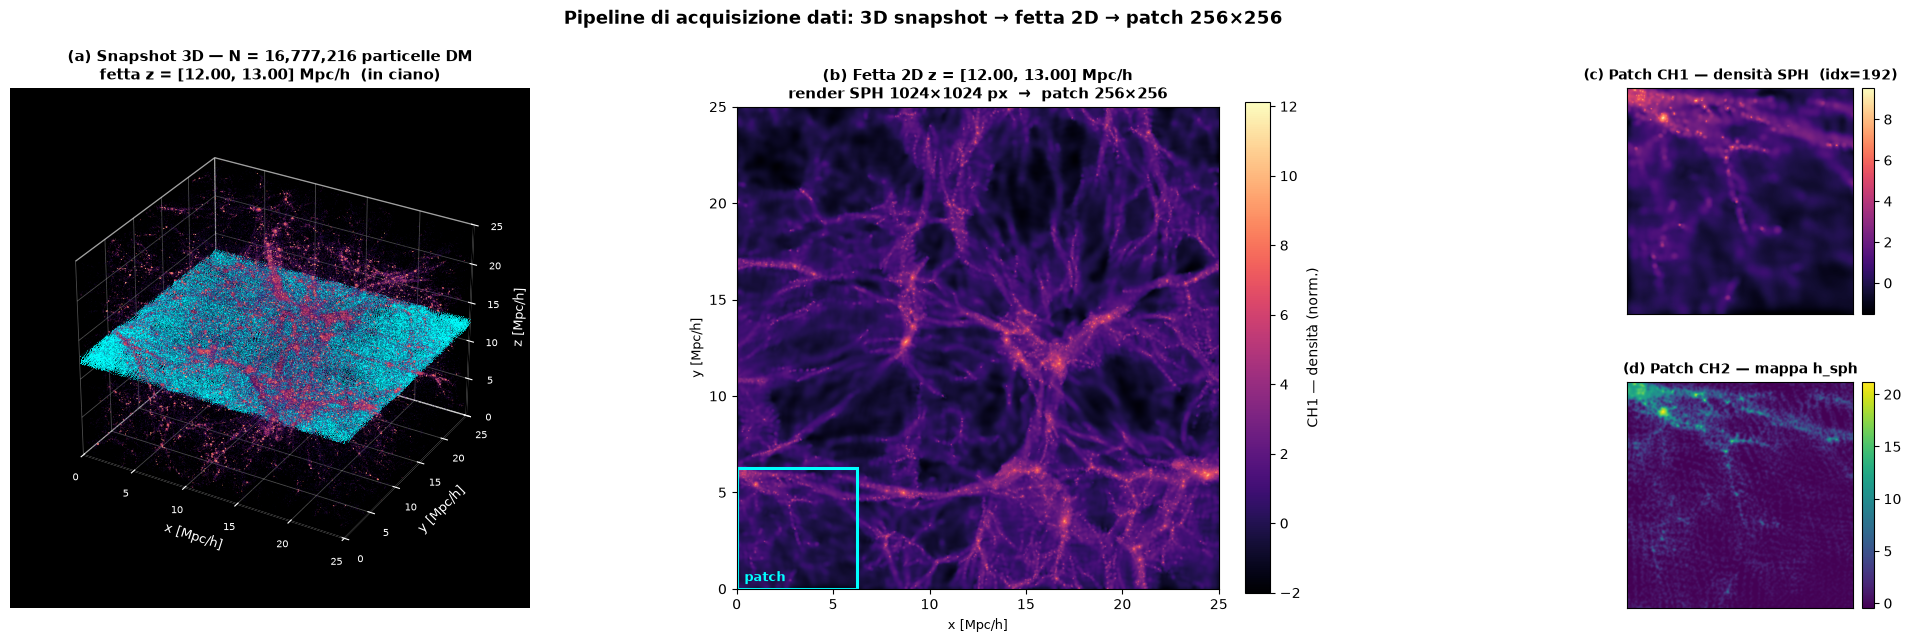

In [24]:
# %% ── 12. Visualizzazione pipeline (stile cosmic web) ───────────────────────
from matplotlib.patches import Rectangle

# ── Parametri ────────────────────────────────────────────────────────────
SLICE_IDX_SHOW  = 12       # fetta da mostrare
PATCH_LOCAL_IDX = None     # None → auto (max heatmap nella fetta), oppure 0..15
N_3D_SHOW       = 400_000  # ↓ se è lento, ↑ se vuoi più dettaglio (max 16.7M)
SEED_3D         = 0

PATCHES_PER_SIDE = IMG_SIZE // PATCH_SIZE   # = 4

# ── Selezione fetta ──────────────────────────────────────────────────────
z_lo_s, z_hi_s, _ = slice_info[SLICE_IDX_SHOW]
mask_slice = (z >= z_lo_s) & (z < z_hi_s)

# ── Selezione patch ──────────────────────────────────────────────────────
base = SLICE_IDX_SHOW * PATCHES_PER_SIDE**2
if PATCH_LOCAL_IDX is None:
    heat_local = Y_heat[base:base + PATCHES_PER_SIDE**2].max(axis=(1, 2))
    PATCH_LOCAL_IDX = int(np.argmax(heat_local))
patch_idx = base + PATCH_LOCAL_IDX
p_row = PATCH_LOCAL_IDX // PATCHES_PER_SIDE
p_col = PATCH_LOCAL_IDX  % PATCHES_PER_SIDE
patch_r0 = p_row * PATCH_SIZE
patch_c0 = p_col * PATCH_SIZE

print(f"Fetta   : idx={SLICE_IDX_SHOW}  z=[{z_lo_s:.2f}, {z_hi_s:.2f}] Mpc/h  "
      f"| {mask_slice.sum():,} particelle")
print(f"Patch   : idx={patch_idx}  (local={PATCH_LOCAL_IDX}, row={p_row}, col={p_col})")

# ── Sottocampionamento per plot 3D ───────────────────────────────────────
rng_3d = np.random.default_rng(SEED_3D)
idx_3d = rng_3d.choice(len(x), size=min(N_3D_SHOW, len(x)), replace=False)
idx_sl = np.where(mask_slice)[0]

# colore per densità locale: -log10(h_sph) → h piccolo = zona densa
d_proxy = -np.log10(h_sph[idx_3d] + 1e-6)
lo, hi  = np.percentile(d_proxy, [2, 98])
d_norm  = np.clip((d_proxy - lo) / (hi - lo), 0, 1)

# ── Figura ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 6.5))
gs  = fig.add_gridspec(1, 3, wspace=0.30,
                       width_ratios=[1.15, 1.0, 0.85],
                       left=0.02, right=0.98, bottom=0.10, top=0.90)

# ── (a) Snapshot 3D stile cosmic web ─────────────────────────────────────
ax3d = fig.add_subplot(gs[0, 0], projection='3d', facecolor='black')

# nube di particelle colorata per densità
ax3d.scatter(x[idx_3d], y[idx_3d], z[idx_3d],
             c=d_norm, cmap='magma',
             s=0.35, alpha=0.35,
             rasterized=True, linewidths=0, depthshade=False)

# piani che delimitano la fetta
xx, yy = np.meshgrid([0, Lbox], [0, Lbox])
for zc_plane in (z_lo_s, z_hi_s):
    ax3d.plot_surface(xx, yy, np.full_like(xx, zc_plane),
                      alpha=0.08, color='cyan',
                      edgecolor='none', shade=False)

# particelle della fetta evidenziate
ax3d.scatter(x[idx_sl], y[idx_sl], z[idx_sl],
             c='cyan', s=0.6, alpha=0.55,
             rasterized=True, linewidths=0, depthshade=False)

# ── stile "cosmic web": griglia bianca su sfondo nero ────────────────────
ax3d.set_xlabel('x [Mpc/h]', color='white', fontsize=9)
ax3d.set_ylabel('y [Mpc/h]', color='white', fontsize=9)
ax3d.set_zlabel('z [Mpc/h]', color='white', fontsize=9)
ax3d.tick_params(colors='white', labelsize=7)
for axis in (ax3d.xaxis, ax3d.yaxis, ax3d.zaxis):
    axis.pane.set_facecolor((0, 0, 0, 1.0))
    axis.pane.set_edgecolor((1, 1, 1, 0.35))
    axis._axinfo["grid"]["color"]     = (1, 1, 1, 0.30)
    axis._axinfo["grid"]["linewidth"] = 0.6
    axis._axinfo["axisline"]["color"] = (1, 1, 1, 0.6)

ax3d.set_xlim(0, Lbox); ax3d.set_ylim(0, Lbox); ax3d.set_zlim(0, Lbox)
ax3d.set_box_aspect([1.15, 1, 0.85], zoom=0.85)  
ax3d.set_title(f"(a) Snapshot 3D — N = {n_particles:,} particelle DM\n"
               f"fetta z = [{z_lo_s:.2f}, {z_hi_s:.2f}] Mpc/h  (in ciano)",
               fontsize=11, fontweight='bold')

# ── (b) Fetta 2D + riquadro patch ────────────────────────────────────────
ax2d = fig.add_subplot(gs[0, 1])
im = ax2d.imshow(images_density_norm[SLICE_IDX_SHOW], cmap='magma',
                 origin='lower', extent=[0, Lbox, 0, Lbox])
ax2d.add_patch(Rectangle((patch_c0 / IMG_SIZE * Lbox, patch_r0 / IMG_SIZE * Lbox),
                         PATCH_SIZE / IMG_SIZE * Lbox, PATCH_SIZE / IMG_SIZE * Lbox,
                         linewidth=2.2, edgecolor='cyan', facecolor='none'))
ax2d.text(patch_c0 / IMG_SIZE * Lbox + 0.4,
          patch_r0 / IMG_SIZE * Lbox + 0.4,
          'patch', color='cyan', fontsize=9, fontweight='bold')
ax2d.set_xlabel('x [Mpc/h]', fontsize=9)
ax2d.set_ylabel('y [Mpc/h]', fontsize=9)
ax2d.set_title(f"(b) Fetta 2D z = [{z_lo_s:.2f}, {z_hi_s:.2f}] Mpc/h\n"
               f"render SPH {IMG_SIZE}×{IMG_SIZE} px  →  patch {PATCH_SIZE}×{PATCH_SIZE}",
               fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax2d, fraction=0.046, label='CH1 — densità (norm.)')

# ── (c) Patch nei 2 canali ───────────────────────────────────────────────
gs_in = gs[0, 2].subgridspec(2, 1, hspace=0.30)
ax_p1 = fig.add_subplot(gs_in[0])
ax_p2 = fig.add_subplot(gs_in[1])

im1 = ax_p1.imshow(X[patch_idx, 0], cmap='magma',   origin='lower')
ax_p1.set_title(f"(c) Patch CH1 — densità SPH  (idx={patch_idx})",
                fontsize=10, fontweight='bold')
ax_p1.set_xticks([]); ax_p1.set_yticks([])
plt.colorbar(im1, ax=ax_p1, fraction=0.046, pad=0.02)

im2 = ax_p2.imshow(X[patch_idx, 1], cmap='viridis', origin='lower')
ax_p2.set_title("(d) Patch CH2 — mappa h_sph",
                fontsize=10, fontweight='bold')
ax_p2.set_xticks([]); ax_p2.set_yticks([])
plt.colorbar(im2, ax=ax_p2, fraction=0.046, pad=0.02)

plt.suptitle("Pipeline di acquisizione dati: 3D snapshot → fetta 2D → patch 256×256",
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(OUTPUT_DIR, "pipeline_visualization.png"),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()